In [ ]:
import pandas as pd
#Ekstraksi fitur
import nltk
from nltk.tokenize import sent_tokenize
#Preprocessing
import re
from nltk.corpus import stopwords
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer, TfidfTransformer
#Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity
#Graph
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
csv_path = 'https://raw.githubusercontent.com/ach-Ilhamf/data_csv/main/data_berita.csv'
df = pd.read_csv(csv_path)
df.head(10)

,Judul,Berita
0,"Dapat Nomor Urut 3, Ganjar: Persatuan Indonesia","Menurut dia, semangat persatuan Indonesia itu..."
1,"Prabowo: Kalau Pemilu Curang, Mengkhianati Ban...","JAKARTA, KOMPAS.com - Calon presiden (capres) ..."
2,Nestle Indonesia PHK 126 Karyawan di Pabrik Ja...,"JAKARTA, KOMPAS.com - PT Nestle Indonesia mela..."
3,Lirik dan Chord Lagu I Tried to Leave You - Le...,Lagu bergenre pop tersebut dirilis pada 1988 m...
4,"Lirik Lagu Another Life, Lagu Baru dari PinkPa...",Di lagu ini ia berkolaborasi dengan penyanyi a...
5,Penderita Diabetes Tetap Sehat dengan Menerapk...,"Sebagai informasi, penyakit diabetes terbagi d..."
6,Jalan Tol Akses Stasiun Kereta Cepat Whoosh Ka...,"JAKARTA, KOMPAS.com - Kementerian Pekerjaan Um..."
7,Penyedap Rasa Sintetis: Pengertian dan Contohnya,KOMPAS.com – Penyedap rasa adalah salah satu b...
8,"Gibran: Kalau Ada Kecurangan Pemilu 2024, Sila...","Menurut dia, jika terjadi kecurangan di Pemil..."
9,"Tak Ajak Relawan ke KPU Saat Ambil Nomor Urut,...","JAKARTA, KOMPAS.com - Calon presiden (capres) ..."


In [ ]:
berita = df["Berita"].iloc[0]
berita

' Menurut dia, semangat persatuan Indonesia itu penting agar masyarakat Indonesia tidak terpecah belah akibat proses Pemilihan Umum (Pemilu 2024).\n "Jadi kita mendapatkan nomor 3 itu pas, sesuai dengan sila ketiga \'Persatuan Indonesia\', kita satukan semuanya dalam proses politik yang menggembirakan," kata Ganjar dalam acara pengundian nomor urut di Kantor KPU, Jakarta, Selasa (14/11/2023).\n Ganjar menuturkan, masyarakat seharusnya mendapat kebahagiaan dalam proses pelaksanaan pemilu. Namun, menurut dia, publik justru disuguhi drama yang menggelisahkan.\n "Ada tokoh agama, ada guru-guru bangsa, ada seniman, ada budayawan, ada teman-teman jurnalis, ada para pemred, para aktivis mahasiswa, dan semuanya sedang menyuarakan kegelisahan itu," kata dia.\n Mantan Gubernur Jawa Tengah ini pun menegaskan bahwa semua pihak harus mengupayakan jalannya demokrasi yang menurutnya belum baik-baik saja.\n Ia mengatakan, perjalanan demokrasi layaknya aliran ait yang terkadang lurus, tapi bisa berliku

# Preprocessing

In [ ]:
# Tahap 1: Menghapus karakter non-alphanumeric kecuali spasi dan titik
text_no_special_chars = re.sub(r'[^\w\s.]', '', berita)
text_no_special_chars

' Menurut dia semangat persatuan Indonesia itu penting agar masyarakat Indonesia tidak terpecah belah akibat proses Pemilihan Umum Pemilu 2024.\n Jadi kita mendapatkan nomor 3 itu pas sesuai dengan sila ketiga Persatuan Indonesia kita satukan semuanya dalam proses politik yang menggembirakan kata Ganjar dalam acara pengundian nomor urut di Kantor KPU Jakarta Selasa 14112023.\n Ganjar menuturkan masyarakat seharusnya mendapat kebahagiaan dalam proses pelaksanaan pemilu. Namun menurut dia publik justru disuguhi drama yang menggelisahkan.\n Ada tokoh agama ada guruguru bangsa ada seniman ada budayawan ada temanteman jurnalis ada para pemred para aktivis mahasiswa dan semuanya sedang menyuarakan kegelisahan itu kata dia.\n Mantan Gubernur Jawa Tengah ini pun menegaskan bahwa semua pihak harus mengupayakan jalannya demokrasi yang menurutnya belum baikbaik saja.\n Ia mengatakan perjalanan demokrasi layaknya aliran ait yang terkadang lurus tapi bisa berlikuliku seperti yang ia anggap terjadi 

In [ ]:
# Tahap 2: Mengubah teks menjadi huruf kecil (case folding)
text_lowercase = text_no_special_chars.lower()
text_lowercase

' menurut dia semangat persatuan indonesia itu penting agar masyarakat indonesia tidak terpecah belah akibat proses pemilihan umum pemilu 2024.\n jadi kita mendapatkan nomor 3 itu pas sesuai dengan sila ketiga persatuan indonesia kita satukan semuanya dalam proses politik yang menggembirakan kata ganjar dalam acara pengundian nomor urut di kantor kpu jakarta selasa 14112023.\n ganjar menuturkan masyarakat seharusnya mendapat kebahagiaan dalam proses pelaksanaan pemilu. namun menurut dia publik justru disuguhi drama yang menggelisahkan.\n ada tokoh agama ada guruguru bangsa ada seniman ada budayawan ada temanteman jurnalis ada para pemred para aktivis mahasiswa dan semuanya sedang menyuarakan kegelisahan itu kata dia.\n mantan gubernur jawa tengah ini pun menegaskan bahwa semua pihak harus mengupayakan jalannya demokrasi yang menurutnya belum baikbaik saja.\n ia mengatakan perjalanan demokrasi layaknya aliran ait yang terkadang lurus tapi bisa berlikuliku seperti yang ia anggap terjadi 

In [ ]:
# Tahap 3: Menghapus stopwords
stop_words = set(stopwords.words('indonesian'))
stop_words.discard('tidak')
words = text_lowercase.split()
filtered_words = [word for word in words if word.lower() not in stop_words]
join_text = ' '.join(filtered_words)
join_text

'semangat persatuan indonesia masyarakat indonesia tidak terpecah belah akibat proses pemilihan pemilu 2024. nomor 3 pas sesuai sila ketiga persatuan indonesia satukan proses politik menggembirakan ganjar acara pengundian nomor urut kantor kpu jakarta selasa 14112023. ganjar masyarakat kebahagiaan proses pelaksanaan pemilu. publik disuguhi drama menggelisahkan. tokoh agama guruguru bangsa seniman budayawan temanteman jurnalis pemred aktivis mahasiswa menyuarakan kegelisahan dia. mantan gubernur jawa mengupayakan jalannya demokrasi menurutnya baikbaik saja. perjalanan demokrasi layaknya aliran ait terkadang lurus berlikuliku anggap ini. percayalah air mengalir mengikuti arah batinnya tidak dibendung bendungan paksakan tetep mencari jalannya muara ganjar. muara muara demokrasi idamidamkan kesepakatam mesti jaga dia. pasangan ganjar pranowomahfud md nomor urut 3 anies baswedanmuhaimin iskandar nomor urut 1 prabowo subiantogibran rakabuming nomor 2.'

In [ ]:
# Tahap 3: Tokenisasi Kalimat
def sent_tokenize(teks):
    # Memisahkan teks menjadi kalimat menggunakan regex
    kalimat = re.split(r'(?<=[.!?]) +', teks)
    return kalimat
kalimat = sent_tokenize(join_text)
kalimat

['semangat persatuan indonesia masyarakat indonesia tidak terpecah belah akibat proses pemilihan pemilu 2024.',
 'nomor 3 pas sesuai sila ketiga persatuan indonesia satukan proses politik menggembirakan ganjar acara pengundian nomor urut kantor kpu jakarta selasa 14112023.',
 'ganjar masyarakat kebahagiaan proses pelaksanaan pemilu.',
 'publik disuguhi drama menggelisahkan.',
 'tokoh agama guruguru bangsa seniman budayawan temanteman jurnalis pemred aktivis mahasiswa menyuarakan kegelisahan dia.',
 'mantan gubernur jawa mengupayakan jalannya demokrasi menurutnya baikbaik saja.',
 'perjalanan demokrasi layaknya aliran ait terkadang lurus berlikuliku anggap ini.',
 'percayalah air mengalir mengikuti arah batinnya tidak dibendung bendungan paksakan tetep mencari jalannya muara ganjar.',
 'muara muara demokrasi idamidamkan kesepakatam mesti jaga dia.',
 'pasangan ganjar pranowomahfud md nomor urut 3 anies baswedanmuhaimin iskandar nomor urut 1 prabowo subiantogibran rakabuming nomor 2.']

# TF-IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(kalimat)

terms = tfidf_vectorizer.get_feature_names_out()
tfidf = pd.DataFrame(data=tfidf_matrix.toarray(), columns=terms)
tfidf

,14112023,2024,acara,agama,air,ait,akibat,aktivis,aliran,anggap,...,sesuai,sila,subiantogibran,temanteman,terkadang,terpecah,tetep,tidak,tokoh,urut
0,0.000000,0.284735,0.000000,0.000000,0.000000,0.000000,0.284735,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.284735,0.000000,0.242051,0.000000,0.000000
1,0.223334,0.000000,0.223334,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.223334,0.223334,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.189854
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.269949,0.000000,0.000000,0.000000,0.269949,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.269949,0.000000,0.000000,0.000000,0.000000,0.269949,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.323539,0.000000,0.000000,0.323539,0.323539,...,0.000000,0.000000,0.000000,0.000000,0.323539,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.271111,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.271111,0.230469,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.230438,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.391787


# Cosine Similarity

In [ ]:
# Menghitung cosine similarity antara semua pasangan kalimat
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Membuat DataFrame untuk cosine similarity
cosine_sim_df = pd.DataFrame(cosine_sim, columns=range(len(kalimat)), index=range(len(kalimat)))

# Menampilkan matriks cosine similarity
cosine_sim_df

,0,1,2,3,4,5,6,7,8,9
0,1.000000,0.173037,0.270180,0.0,0.000000,0.000000,0.000000,0.055785,0.000000,0.000000
1,0.173037,1.000000,0.105019,0.0,0.000000,0.000000,0.000000,0.026473,0.000000,0.320031
2,0.270180,0.105019,1.000000,0.0,0.000000,0.000000,0.000000,0.056282,0.000000,0.047839
3,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.068265,0.000000
5,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,0.062209,0.068104,0.067284,0.000000
6,0.000000,0.000000,0.000000,0.0,0.000000,0.062209,1.000000,0.000000,0.062624,0.000000
7,0.055785,0.026473,0.056282,0.0,0.000000,0.068104,0.000000,1.000000,0.137118,0.027315
8,0.000000,0.000000,0.000000,0.0,0.068265,0.067284,0.062624,0.137118,1.000000,0.000000
9,0.000000,0.320031,0.047839,0.0,0.000000,0.000000,0.000000,0.027315,0.000000,1.000000


# Graph

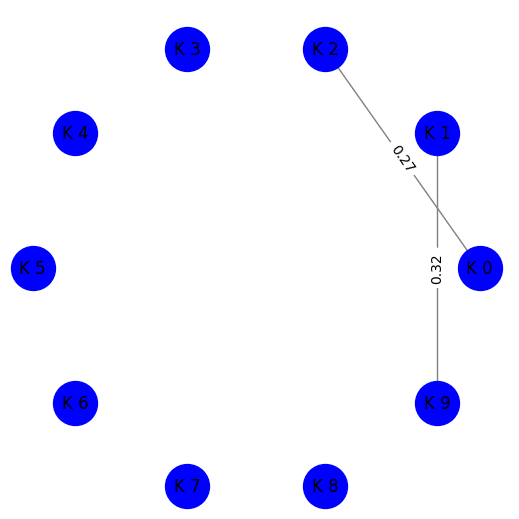

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Tambahkan node (kalimat)
for i in range(len(cosine_sim)):
    G.add_node(i)

# Tambahkan edge (hubungan) antara kalimat berdasarkan cosine similarity
for i in range(len(cosine_sim)):
    for j in range(len(cosine_sim)):
        similarity = cosine_sim[i][j]
        if similarity > 0.2 and i != j :  # Ambang batas untuk menentukan hubungan
            G.add_edge(i, j, weight=similarity)

# Visualisasikan grafik dengan tata letak "circular" dan penyesuaian visual
pos = nx.circular_layout(G)

# Membuat label node yang hanya menggunakan nomor indeks
labels = {i: f'K {i}' for i in G.nodes()}

edge_labels = {(i, j): round(data['weight'], 2) for i, j, data in G.edges(data=True)}

# Atur ukuran node
node_size = 1000

# Atur warna node dan edge
node_color = 'blue'
edge_color = 'gray'

plt.figure(figsize=(5, 5))
nx.draw(G, pos, with_labels=True, labels=labels, node_size=node_size, node_color=node_color, edge_color=edge_color)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()


#Closeness Centrality

In [ ]:
# Menghitung closeness centrality
closeness_centrality = nx.closeness_centrality(G)

# Membuat DataFrame dari nilai Closeness Centrality
centrality_df = pd.DataFrame(closeness_centrality.items(), columns=['Node', 'Closeness Centrality'])

# Mengurutkan DataFrame berdasarkan Closeness Centrality dari yang terbesar
centrality_df_sorted = centrality_df.sort_values(by='Closeness Centrality', ascending=False)

# Menampilkan tabel Closeness Centrality yang telah diurutkan
centrality_df_sorted

,Node,Closeness Centrality
0,0,0.111111
1,1,0.111111
2,2,0.111111
9,9,0.111111
3,3,0.000000
4,4,0.000000
5,5,0.000000
6,6,0.000000
7,7,0.000000
8,8,0.000000


In [ ]:
# Mengambil tiga baris teratas dari DataFrame yang sudah diurutkan
top_three_closeness = centrality_df_sorted.head(3)

# Mendapatkan indeks node dari tiga baris teratas
top_node_closeness = top_three_closeness['Node']

# Menampilkan kalimat yang sesuai dengan node-node teratas
for node_index in top_node_closeness:
    print(f"{node_index}: {kalimat[node_index]}")

0: semangat persatuan indonesia masyarakat indonesia tidak terpecah belah akibat proses pemilihan pemilu 2024.
1: nomor 3 pas sesuai sila ketiga persatuan indonesia satukan proses politik menggembirakan ganjar acara pengundian nomor urut kantor kpu jakarta selasa 14112023.
2: ganjar masyarakat kebahagiaan proses pelaksanaan pemilu.


# Page Rank

In [ ]:
# Menghitung pagerank
pagerank = nx.pagerank(G)

# Membuat DataFrame dari nilai Closeness Centrality
pagerank_df = pd.DataFrame(pagerank.items(), columns=['Node', 'Page Rank'])

# Mengurutkan DataFrame berdasarkan Closeness Centrality dari yang terbesar
pagerank_df_sorted = pagerank_df.sort_values(by='Page Rank', ascending=False)

# Menampilkan tabel Closeness Centrality yang telah diurutkan
pagerank_df_sorted

,Node,Page Rank
0,0,0.204081
1,1,0.204081
2,2,0.204081
9,9,0.204081
3,3,0.030613
4,4,0.030613
5,5,0.030613
6,6,0.030613
7,7,0.030613
8,8,0.030613


In [ ]:
# Mengambil tiga baris teratas dari DataFrame yang sudah diurutkan
top_three_pagerank = pagerank_df_sorted.head(3)

# Mendapatkan indeks node dari tiga baris teratas
top_node_pagerank = top_three_pagerank['Node']

# Menampilkan kalimat yang sesuai dengan node-node teratas
for node_index in top_node_pagerank:
    print(f"Node {node_index}: {kalimat[node_index]}")

Node 0: semangat persatuan indonesia masyarakat indonesia tidak terpecah belah akibat proses pemilihan pemilu 2024.
Node 1: nomor 3 pas sesuai sila ketiga persatuan indonesia satukan proses politik menggembirakan ganjar acara pengundian nomor urut kantor kpu jakarta selasa 14112023.
Node 2: ganjar masyarakat kebahagiaan proses pelaksanaan pemilu.


#Eigen Vector

In [ ]:
# Menghitung eigenvector
eigenvector = nx.eigenvector_centrality(G)

# Membuat DataFrame dari nilai Closeness Centrality
eigenvector_df = pd.DataFrame(eigenvector.items(), columns=['Node', 'Eigen Vector'])

# Mengurutkan DataFrame berdasarkan Closeness Centrality dari yang terbesar
eigenvector_df_sorted = eigenvector_df.sort_values(by='Eigen Vector', ascending=False)

# Menampilkan tabel Closeness Centrality yang telah diurutkan
eigenvector_df_sorted

,Node,Eigen Vector
0,0,5.000000e-01
1,1,5.000000e-01
2,2,5.000000e-01
9,9,5.000000e-01
3,3,9.536743e-07
4,4,9.536743e-07
5,5,9.536743e-07
6,6,9.536743e-07
7,7,9.536743e-07
8,8,9.536743e-07


In [ ]:
# Mengambil tiga baris teratas dari DataFrame yang sudah diurutkan
top_three_eigenvector = eigenvector_df_sorted.head(3)

# Mendapatkan indeks node dari tiga baris teratas
top_node_eigenvector = top_three_eigenvector['Node']

# Menampilkan kalimat yang sesuai dengan node-node teratas
for node_index in top_node_eigenvector:
    print(f"Node {node_index}: {kalimat[node_index]}")

Node 0: semangat persatuan indonesia masyarakat indonesia tidak terpecah belah akibat proses pemilihan pemilu 2024.
Node 1: nomor 3 pas sesuai sila ketiga persatuan indonesia satukan proses politik menggembirakan ganjar acara pengundian nomor urut kantor kpu jakarta selasa 14112023.
Node 2: ganjar masyarakat kebahagiaan proses pelaksanaan pemilu.
